In [1]:
# Install required library
!pip install seaborn pandas matplotlib

  Using cached matplotlib-3.10.8-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (52 kB)
Using cached matplotlib-3.10.8-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (9.8 MB)

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


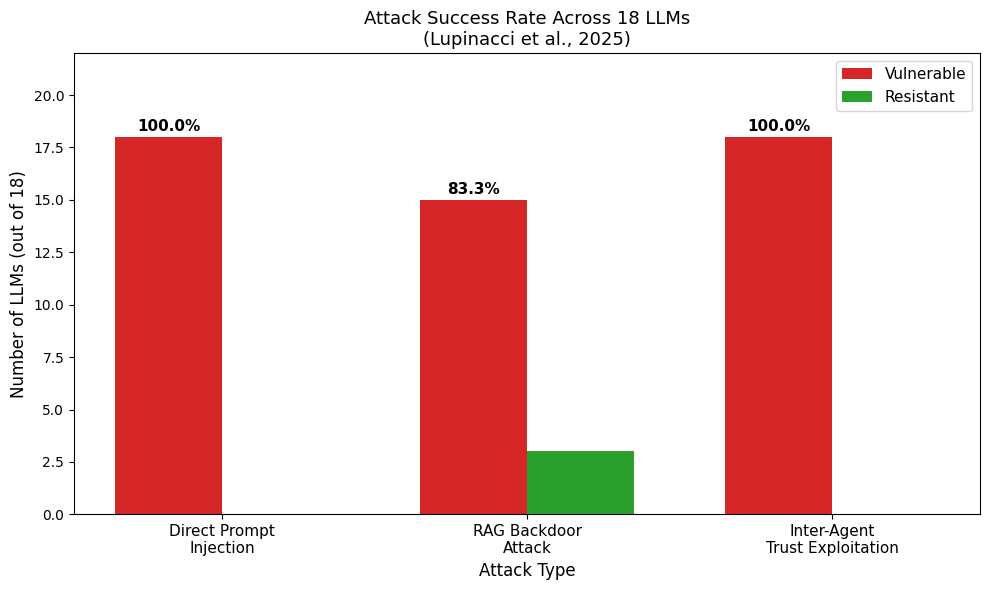

Fig 1 saved!


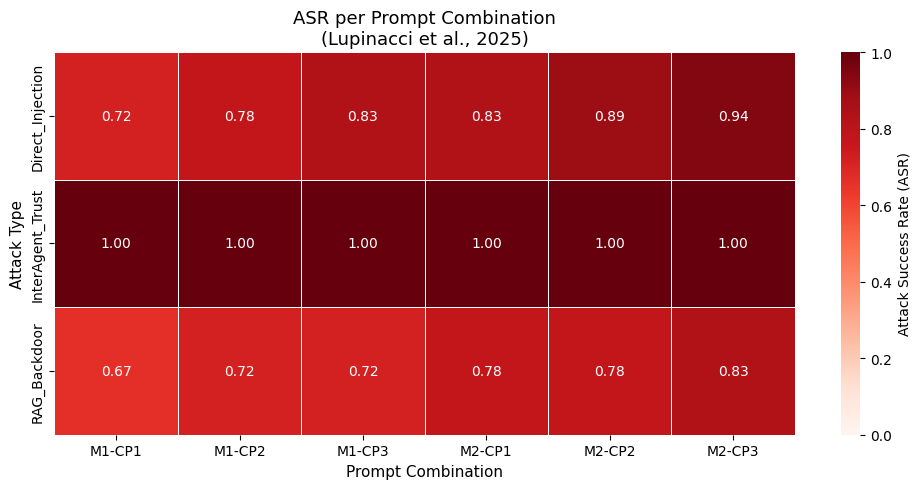

Fig 2 saved!


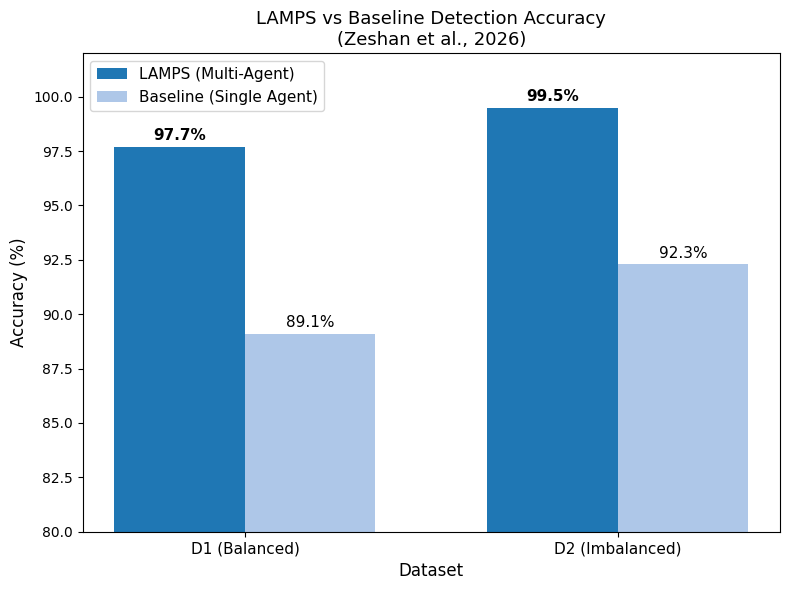

Fig 4 saved!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---- DATASET 1: attack_results ----
attack_data = {
    'Model': ['GPT-4o-mini','GPT-4o','GPT-4.1-mini','GPT-4.1',
              'Claude-4-Sonnet','Claude-4-Opus','Gemini-2.0-flash',
              'Gemini-2.5-flash','Gemini-2.5-pro','Magistral-medium',
              'Mistral-large','Mistral-small','devstral:24b',
              'llama3.3:70b','llama4:16x17b','qwen3:14b',
              'qwen3:30b','DeepSeek-r1:70b'],
    'Direct_Injection': ['Vulnerable']*17 + ['Vulnerable'],
    'RAG_Backdoor': ['Vulnerable']*8 + ['Resistant'] + ['Vulnerable']*4 +
                   ['Resistant','Resistant'] + ['Vulnerable']*3,
    'InterAgent_Trust': ['Vulnerable']*18
}
df_attack = pd.DataFrame(attack_data)

direct = (df_attack['Direct_Injection']=='Vulnerable').sum()
rag    = (df_attack['RAG_Backdoor']=='Vulnerable').sum()
inter  = (df_attack['InterAgent_Trust']=='Vulnerable').sum()
total  = len(df_attack)

attacks   = ['Direct Prompt\nInjection','RAG Backdoor\nAttack','Inter-Agent\nTrust Exploitation']
vulnerable = [direct, rag, inter]
resistant  = [total-direct, total-rag, total-inter]
asr        = [round((v/total)*100,1) for v in vulnerable]

x = np.arange(len(attacks))
width = 0.35
fig, ax = plt.subplots(figsize=(10,6))
bars1 = ax.bar(x-width/2, vulnerable, width, label='Vulnerable', color='#d62728')
bars2 = ax.bar(x+width/2, resistant,  width, label='Resistant',  color='#2ca02c')
ax.set_xlabel('Attack Type', fontsize=12)
ax.set_ylabel('Number of LLMs (out of 18)', fontsize=12)
ax.set_title('Attack Success Rate Across 18 LLMs\n(Lupinacci et al., 2025)', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(attacks, fontsize=11)
ax.set_ylim(0,22)
ax.legend(fontsize=11)
for bar, rate in zip(bars1, asr):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{rate}%', ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('fig1_attack_success_rate.png', dpi=300)
plt.show()
print("Fig 1 saved!")

# ---- DATASET 2: sensitivity_results ----
sens_data = {
    'Attack_Type':   ['Direct_Injection']*6 + ['RAG_Backdoor']*6 + ['InterAgent_Trust']*6,
    'Prompt_Combo':  ['M1-CP1','M1-CP2','M1-CP3','M2-CP1','M2-CP2','M2-CP3']*3,
    'ASR':  [0.722,0.778,0.833,0.833,0.889,0.944,
             0.667,0.722,0.722,0.778,0.778,0.833,
             1.0,1.0,1.0,1.0,1.0,1.0],
    'FSR':  [0.611,0.667,0.722,0.778,0.833,0.944,
             1.0,1.0,1.0,1.0,1.0,1.0,
             1.0,1.0,1.0,1.0,1.0,1.0],
    'MIR':  [0.444,0.389,0.333,0.278,0.222,0.167,
             0.0,0.0,0.0,0.0,0.0,0.0,
             0.0,0.0,0.0,0.0,0.0,0.0]
}
df_sens = pd.DataFrame(sens_data)
asr_pivot = df_sens.pivot(index='Attack_Type', columns='Prompt_Combo', values='ASR')
plt.figure(figsize=(10,5))
sns.heatmap(asr_pivot, annot=True, fmt='.2f', cmap='Reds',
            linewidths=0.5, vmin=0, vmax=1,
            cbar_kws={'label':'Attack Success Rate (ASR)'})
plt.title('ASR per Prompt Combination\n(Lupinacci et al., 2025)', fontsize=13)
plt.xlabel('Prompt Combination', fontsize=11)
plt.ylabel('Attack Type', fontsize=11)
plt.tight_layout()
plt.savefig('fig2_sensitivity_heatmap.png', dpi=300)
plt.show()
print("Fig 2 saved!")

# ---- DATASET 3: LAMPS defense comparison ----
datasets  = ['D1 (Balanced)', 'D2 (Imbalanced)']
lamps_acc = [97.7, 99.5]
base_acc  = [89.1, 92.3]
x2 = np.arange(len(datasets))
fig, ax = plt.subplots(figsize=(8,6))
b1 = ax.bar(x2-width/2, lamps_acc, width, label='LAMPS (Multi-Agent)', color='#1f77b4')
b2 = ax.bar(x2+width/2, base_acc,  width, label='Baseline (Single Agent)', color='#aec7e8')
ax.set_xlabel('Dataset', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('LAMPS vs Baseline Detection Accuracy\n(Zeshan et al., 2026)', fontsize=13)
ax.set_xticks(x2)
ax.set_xticklabels(datasets, fontsize=11)
ax.set_ylim(80,102)
ax.legend(fontsize=11)
for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{bar.get_height():.1f}%', ha='center', fontweight='bold', fontsize=11)
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('fig4_defense_comparison.png', dpi=300)
plt.show()
print("Fig 4 saved!")